In [1]:
import matplotlib.pyplot as plt
import numpy as np
from files.utils import ctft

## Άσκηση - Δειγματοληψία και aliasing

Συζητήσαμε στο Κεφάλαιο αυτό για την έννοια της δειγματοληψίας, δηλ. της μετατροπής ενός σήματος συνεχούς χρόνου σε **διακριτού** χρόνου (ένα βήμα πριν το "ψηφιακό" σήμα). Η δειγματοληψία που περιγράψαμε ονομάζεται **ιδανική** καθώς, όπως είδατε, περιλαμβάνει ιδανικά φίλτρα και συναρτήσεις Δέλτα στη διαδικασία, που είναι "πράγματα" που δεν υπάρχουν στην πραγματικότητα. 

Η δειγματοληψία στην `Python` είναι πολύ απλή υπόθεση - ουσιαστικά σε όλες τις ασκήσεις `Python` που κάνατε ως τώρα, χρησιμοποιούσατε δειγματοληψία χωρίς να το ξέρετε!😄

Για παράδειγμα, ένας άξονας χρόνου της μορφής:

In [2]:
tt = np.arange(start=0, stop=1, step=0.001)

σημαίνει ότι δειγματοληπτείτε το συνεχές διάστημα $[0, 1)$ ομοιόμορφα σε $1000$ σημεία, δηλ. με ρυθμό $f_s = 1/0.001 = 1000$ Hz. 

Σε όλες τις προηγούμενες ασκήσεις που συναντήσατε, η συχνότητα δειγματοληψίας ήταν κατάλληλη για τα παραδείγματα που λύνατε, δίνοντάς σας τους άξονες του χρόνου έτοιμους τις περισσότερες φορές. 

Τώρα, θα αναλάβετε εσείς τη διαδικασία αυτή, και θα δείτε τι αποτελέσματα έχει μια δειγματοληψία που **ΔΕΝ** υπακούει στο θεώρημα του Shannon.

α) Θεωρήστε μια συχνότητα δειγματοληψίας ίση με $2000$ Hz, η οποία θα είναι σταθερή για όλα τα παρακάτω ερωτήματα. Ξέρετε ότι με βάση το θεώρημα του Shannon, μπορείτε να αναπαραστήσετε σωστά συχνότητες μέχρι και $1000$ Hz, δηλ. χωρίς να υπάρξει το φαινόμενο του aliasing.

In [3]:
# Συχνότητα δειγματοληψίας
f_s = 2000

β) Δειγματοληπτήστε ομοιόμορφα με αυτή τη συχνότητα το συνεχές διάστημα $[0, 0.05)$.

In [4]:
# Δειγματοληψία του [0, 0.05)
t = np.arange(start=0, stop=0.05, step=1/f_s)

γ) Δημιουργήστε παρακάτω ένα συνημίτονο των $400$ Hz σε αυτό το διάστημα

In [5]:
# Συνημίτονο
x = np.cos(2*np.pi*400*t)

δ) Τυπώστε το δειγματοληπτημένο σήμα με τις εντολές που βλέπετε παρακάτω. Το αποτέλεσμα θα είναι μια **ακολουθία** από τιμές, $x[n]$.

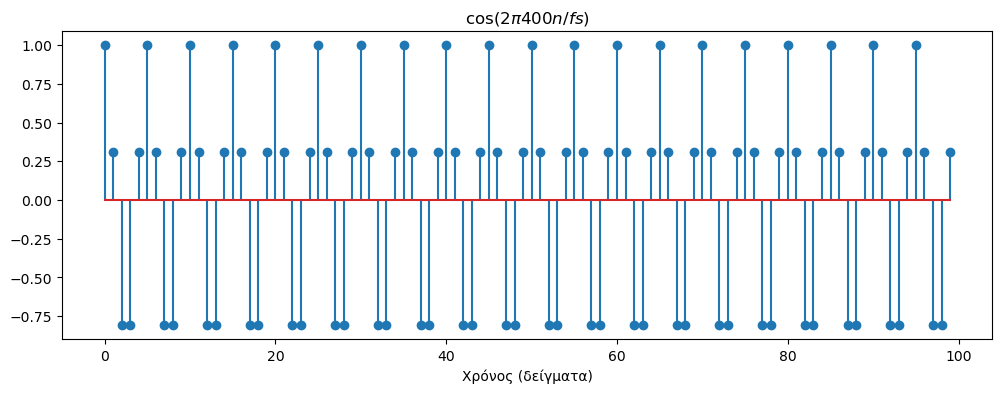

In [6]:
# Δειγματοληπτημένο σήμα
plt.figure(figsize=(12,4))
plt.stem(t*f_s, x)
plt.title("$\cos(2\pi 400 n/fs)$")
plt.xlabel("Χρόνος (δείγματα)")
plt.show()

ε) Ορίστε έναν άξονα $f$ από $-f_s/2$ ως $f_s/2$, δηλ. στο $[-f_s/2, f_s/2)$, για να αναλύσετε το σήμα σας στο χώρο της συχνότητας. Ορίστε το "βήμα" σας στη συχνότητα να είναι $Df = 0.1$ Hz.

In [7]:
# Άξονας συχνοτήτων
df = 0.1
f = np.arange(start=-f_s/2, stop=f_s/2, step=df)

στ) Χρησιμοποιήστε τη συνάρτηση `ctft` για να ελέγξετε το φάσμα πλάτους του (**MONO - αγνοήστε τα υπόλοιπα σχήματα**). Είναι σωστό? Εξηγήστε. Για την αιτιολόγηση, δείτε τις διαφάνειες 20, 21, 22 της Διάλεξης 12!

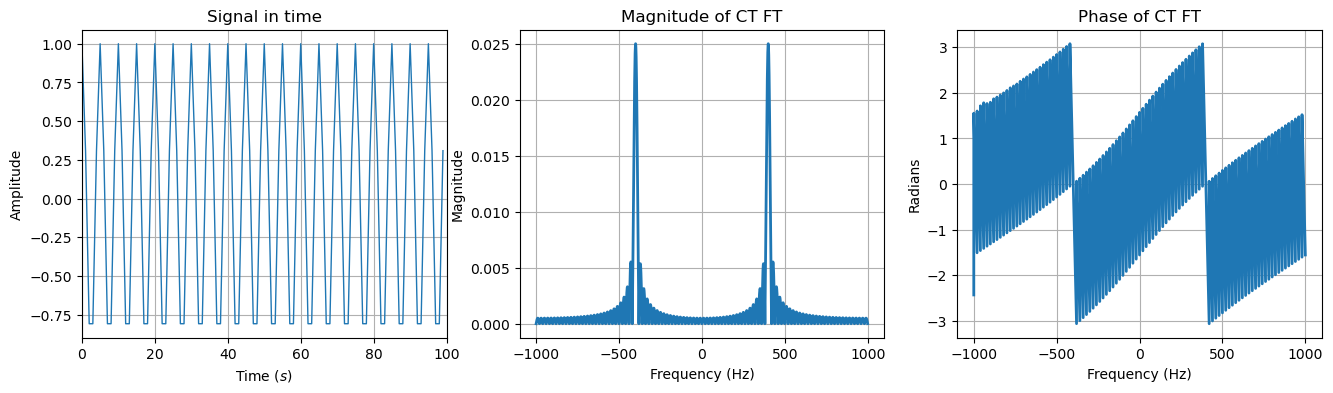

(array([[-6.96599896e-18-5.98034120e-18j],
        [ 1.21475292e-07+7.85271938e-06j],
        [ 4.85783145e-07+1.56978667e-05j],
        ...,
        [ 1.09256961e-06-2.35278771e-05j],
        [ 4.85783143e-07-1.56978666e-05j],
        [ 1.21475291e-07-7.85271934e-06j]]),
 array([[9.18093799e-18],
        [7.85365888e-06],
        [1.57053813e-05],
        ...,
        [2.35532314e-05],
        [1.57053813e-05],
        [7.85365885e-06]]),
 array([[-2.43218198],
        [ 1.55532836],
        [ 1.53986039],
        ...,
        [-1.52439243],
        [-1.53986039],
        [-1.55532836]]))

In [8]:
# Έλεγχος
ctft(ss=x, tt=t, ff=f, plot=True)

**Απαντήστε στο παρακάτω κελί:**

Ναι, είναι σωστό, παρατηρούμε δυο συναρτήσεις $\texttt{sinc}()$ πάνω από τις συχνότητες $\pm 400$ Hz. Επειδή το ημίτονο είναι πεπερασμένης διάρκειας, μπορεί να γραφεί ως ένα άπειρης διάρκειας ημίτονο επί ένα πεπερασμένης διάρκειας παράθυρο. Το γινόμενο αυτό οδηγεί στην ύπαρξη συναρτήσεων $\texttt{sinc}()$ στο φάσμα στις θέσεις που θεωρητικά θα αναμέναμε συναρτήσεις Δέλτα.

ζ) Δημιουργήστε τώρα ένα συνημίτονο των $1200$ Hz, στο ίδιο χρονικό διάστημα με πριν.

In [9]:
# Συνημίτονο 1200 Hz
y = np.cos(2*np.pi*1200*t)

η) Ας το τυπώσουμε όπως πριν.

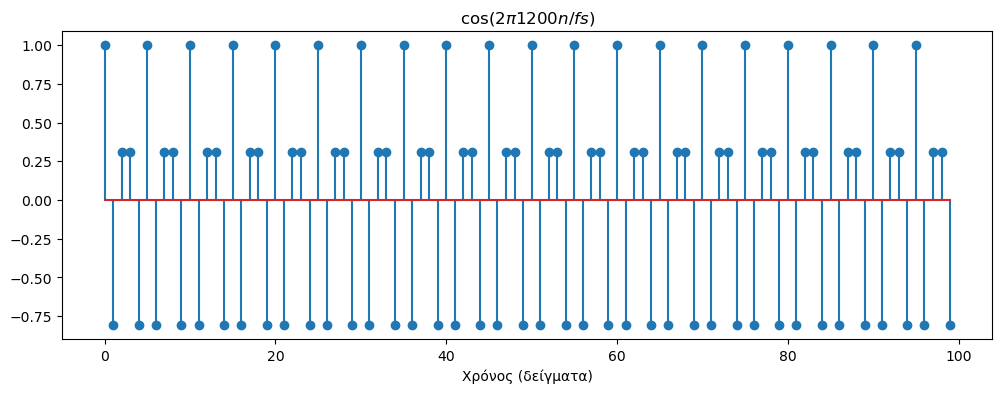

In [10]:
# Γράφημα
plt.figure(figsize=(12,4))
plt.stem(t*f_s, y)
plt.title("$\cos(2\pi 1200 n/fs)$")
plt.xlabel("Χρόνος (δείγματα)")
plt.show()

θ) Χρησιμοποιήστε ξανά τη συνάρτηση `ctft` για να ελέγξετε το φάσμα πλάτους του (**ΜΟΝΟ - αγνοήστε τα υπόλοιπα σχήματα**). Είναι σωστό? Εξηγήστε.

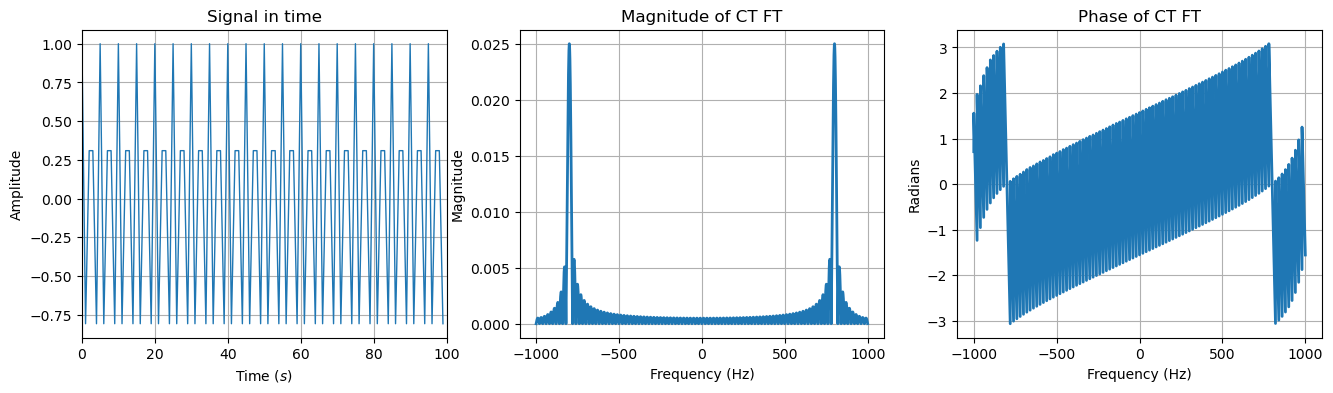

(array([[1.61004023e-17+1.38799320e-17j],
        [1.10442551e-07+7.85289269e-06j],
        [4.41673919e-07+1.56992529e-05j],
        ...,
        [9.93405337e-07-2.35325536e-05j],
        [4.41673917e-07-1.56992528e-05j],
        [1.10442550e-07-7.85289266e-06j]]),
 array([[2.12573626e-17],
        [7.85366928e-06],
        [1.57054645e-05],
        ...,
        [2.35535121e-05],
        [1.57054645e-05],
        [7.85366925e-06]]),
 array([[ 0.71146892],
        [ 1.55673332],
        [ 1.54267031],
        ...,
        [-1.52860729],
        [-1.54267031],
        [-1.55673332]]))

In [11]:
# Έλεγχος
ctft(ss=y, tt=t, ff=f, plot=True)

**Απαντήστε στο παρακάτω κελί:**


Επειδή η συχνότητα του ημιτόνου είναι $1200$ Hz και δειγματοληπτούμε με συχνότητα δειγματοληψίας $2000$ Hz, το θεώρημα του Shannon δεν ικανοποιείται. Αυτό σημαίνει ότι στο φάσμα θα δούμε ξένες συχνότητες, και πράγματι βλέπουμε συχνότητες στα $\pm 800$ Hz και όχι στα $1200$ Hz, όπως θα αναμέναμε.

---
---